In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
!unzip "brain_tumor.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
!ls

binary_data  brain_tumor.zip  sample_data  Testing  Training


In [ ]:
!ls Training

glioma	meningioma  notumor  pituitary


In [ ]:
import os
import shutil

# create folders
os.makedirs('binary_data/train/tumor', exist_ok=True)
os.makedirs('binary_data/train/no_tumor', exist_ok=True)
os.makedirs('binary_data/test/tumor', exist_ok=True)
os.makedirs('binary_data/test/no_tumor', exist_ok=True)

# source folders
train_src = 'Training'
test_src = 'Testing'

# copy training images
for folder in os.listdir(train_src):
    src = os.path.join(train_src, folder)
    if folder.lower() in ['no', 'no_tumor', 'notumor']:
        dst = 'binary_data/train/no_tumor'
    else:
        dst = 'binary_data/train/tumor'
    for img in os.listdir(src):
        shutil.copy(os.path.join(src, img), dst)

# copy testing images
for folder in os.listdir(test_src):
    src = os.path.join(test_src, folder)
    if folder.lower() in ['no', 'no_tumor', 'notumor']:
        dst = 'binary_data/test/no_tumor'
    else:
        dst = 'binary_data/test/tumor'
    for img in os.listdir(src):
        shutil.copy(os.path.join(src, img), dst)

print("DONE")

DONE


In [ ]:
!ls binary_data/train

no_tumor  tumor


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.15
)

train_data = train_datagen.flow_from_directory(
    'binary_data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    'binary_data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    'binary_data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4760 images belonging to 2 classes.
Found 840 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')   # binary output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 224ms/step - accuracy: 0.8128 - loss: 0.4500 - val_accuracy: 0.9714 - val_loss: 0.1297
Epoch 2/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 31s 211ms/step - accuracy: 0.9424 - loss: 0.1685 - val_accuracy: 0.9571 - val_loss: 0.0926
Epoch 3/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 30s 202ms/step - accuracy: 0.9498 - loss: 0.1408 - val_accuracy: 0.9857 - val_loss: 0.0431
Epoch 4/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 30s 200ms/step - accuracy: 0.9588 - loss: 0.1292 - val_accuracy: 0.9607 - val_loss: 0.1276
Epoch 5/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 30s 197ms/step - accuracy: 0.9631 - loss: 0.1104 - val_accuracy: 0.9690 - val_loss: 0.0982
Epoch 6/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 28s 190ms/step - accuracy: 0.9489 - loss: 0.1510 - val_accuracy: 0.9750 - val_loss: 0.0635
Epoch 7/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 28s 189ms/step - accuracy: 0.9636 - loss: 0.1056 - val_accuracy: 0.9786 - val_loss: 0.0852
Epoch 8/25
149/149 ━━━━━━━━━━━━━━━━━━━━ 29s 197ms/step - accuracy: 0.9660 - loss: 0

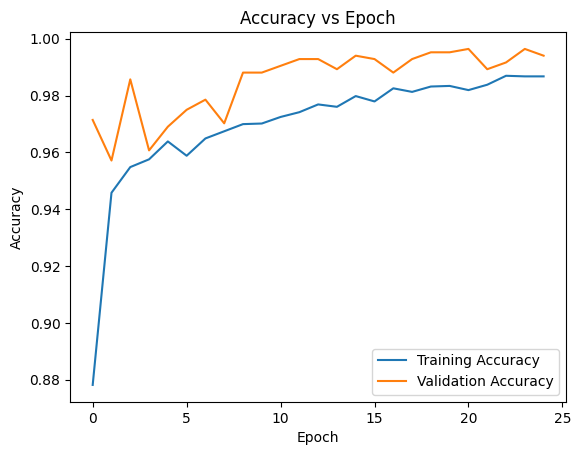

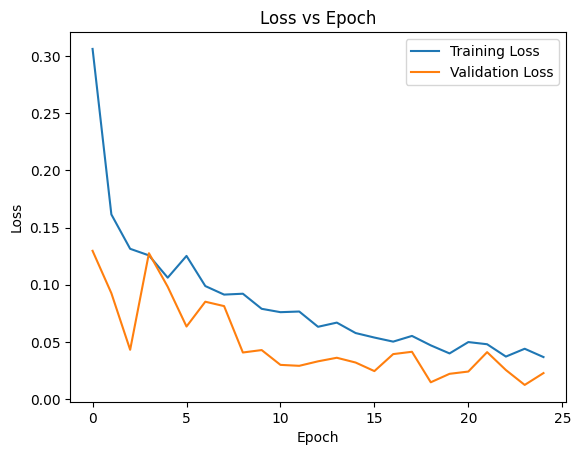

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epoch')
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epoch')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9679 - loss: 0.1258
Test Accuracy: 0.9587500095367432


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# predictions
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

# confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)
print("Confusion Matrix:\n", cm)

# classification report
print("\nClassification Report:\n")
print(classification_report(test_data.classes, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
Confusion Matrix:
 [[ 400    0]
 [  66 1134]]

Classification Report:

              precision    recall  f1-score   support

           0       0.86      1.00      0.92       400
           1       1.00      0.94      0.97      1200

    accuracy                           0.96      1600
   macro avg       0.93      0.97      0.95      1600
weighted avg       0.96      0.96      0.96      1600



In [ ]:
!ls binary_data/test/tumor | head

Te-aug-me_100.jpg
Te-aug-me_101.jpg
Te-aug-me_102.jpg
Te-aug-me_103.jpg
Te-aug-me_10.jpg
Te-aug-me_11.jpg
Te-aug-me_12.jpg
Te-aug-me_13.jpg
Te-aug-me_14.jpg
Te-aug-me_15.jpg


In [ ]:
!ls /content

binary_data  brain_tumor.zip  sample_data  Testing  Training


In [ ]:
!ls /content/binary_data

test  train


In [ ]:
!ls /content/binary_data/test

no_tumor  tumor


In [ ]:
!ls /content/binary_data/test/tumor

Te-aug-me_100.jpg  Te-gl_224.jpg  Te-gl_7.jpg	 Te-me_297.jpg	Te-pi_245.jpg
Te-aug-me_101.jpg  Te-gl_225.jpg  Te-gl_80.jpg	 Te-me_29.jpg	Te-pi_246.jpg
Te-aug-me_102.jpg  Te-gl_226.jpg  Te-gl_81.jpg	 Te-me_2.jpg	Te-pi_247.jpg
Te-aug-me_103.jpg  Te-gl_227.jpg  Te-gl_82.jpg	 Te-me_30.jpg	Te-pi_248.jpg
Te-aug-me_10.jpg   Te-gl_228.jpg  Te-gl_83.jpg	 Te-me_31.jpg	Te-pi_249.jpg
Te-aug-me_11.jpg   Te-gl_229.jpg  Te-gl_84.jpg	 Te-me_32.jpg	Te-pi_24.jpg
Te-aug-me_12.jpg   Te-gl_22.jpg   Te-gl_85.jpg	 Te-me_33.jpg	Te-pi_250.jpg
Te-aug-me_13.jpg   Te-gl_230.jpg  Te-gl_86.jpg	 Te-me_34.jpg	Te-pi_251.jpg
Te-aug-me_14.jpg   Te-gl_231.jpg  Te-gl_87.jpg	 Te-me_35.jpg	Te-pi_252.jpg
Te-aug-me_15.jpg   Te-gl_232.jpg  Te-gl_88.jpg	 Te-me_36.jpg	Te-pi_253.jpg
Te-aug-me_16.jpg   Te-gl_233.jpg  Te-gl_89.jpg	 Te-me_37.jpg	Te-pi_254.jpg
Te-aug-me_17.jpg   Te-gl_234.jpg  Te-gl_8.jpg	 Te-me_38.jpg	Te-pi_255.jpg
Te-aug-me_18.jpg   Te-gl_235.jpg  Te-gl_90.jpg	 Te-me_39.jpg	Te-pi_256.jpg
Te-aug-me_19.jpg   Te-gl_236

In [ ]:
img_path = '/content/binary_data/test/tumor/Te-gl_287.jpg'

In [ ]:
import os
print(os.path.exists('/content/binary_data/test/tumor/Te-gl_287.jpg'))

True


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/binary_data/test/tumor/Te-gl_287.jpg'

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Tumor" if prediction[0][0] > 0.5 else "No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
Tumor


In [ ]:
from google.colab import files
files.upload()

Saving brain_tumor.zip to brain_tumor.zip


In [ ]:
model.save("model.h5")

In [ ]:
from google.colab import files
files.download("model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>